Below is a **Python version of ray reflection (metallic mirror reflection)** with:

* ✔ Physics intuition
* ✔ Formula (LaTeX)
* ✔ Step-by-step explanation table
* ✔ Clean Python code
* ✔ Comments showing “what changed vs before”

---

# 🪞 1. Core Idea: Reflection from a Metal Surface

When a ray hits a smooth metal surface, it does **not scatter randomly**. It reflects like a mirror.

## 📌 Reflection Formula

$$
\mathbf{r} = \mathbf{v} - 2(\mathbf{v} \cdot \mathbf{n})\mathbf{n}
$$

Where:

* $\mathbf{v}$ = incoming ray direction
* $\mathbf{n}$ = surface normal (unit vector)
* $\mathbf{v} \cdot \mathbf{n}$ = projection of velocity onto normal
* $\mathbf{r}$ = reflected direction

---

# 📊 2. Step-by-Step Learning Table

| Step | Formula                                    | Meaning            | Purpose                                   |
| ---- | ------------------------------------------ | ------------------ | ----------------------------------------- |
| 1    | $\mathbf{d} = \mathbf{v} \cdot \mathbf{n}$ | Dot product        | Measures how much ray points into surface |
| 2    | $\mathbf{b} = d \cdot \mathbf{n}$          | Projection vector  | Component of ray along normal             |
| 3    | $2\mathbf{b}$                              | Double projection  | Needed to flip direction                  |
| 4    | $\mathbf{r} = \mathbf{v} - 2\mathbf{b}$    | Reflection formula | Produces mirror direction                 |

---

# 🧠 3. Intuition (Simple)

* Incoming ray goes **into surface**
* Split it into:

  * Parallel to surface
  * Perpendicular (normal direction)
* Flip perpendicular part → gives reflection

---

# 🧾 4. Python Implementation (Ray Tracing Style)

We will build:

* `Vec3` (vector math)
* `reflect()` function
* `MetalMaterial`
* `ray_color()` recursion (like your C++ code)

---

## 🧮 Vector + Reflection Code

```python
import numpy as np

# =========================
# Vec3 (like C++ vec3)
# =========================
class Vec3:
    def __init__(self, x, y, z):
        self.x = x
        self.y = y
        self.z = z

    def __add__(self, other):
        return Vec3(self.x + other.x, self.y + other.y, self.z + other.z)

    def __sub__(self, other):
        return Vec3(self.x - other.x, self.y - other.y, self.z - other.z)

    def __mul__(self, t):
        return Vec3(self.x * t, self.y * t, self.z * t)

    def dot(self, other):
        return self.x*other.x + self.y*other.y + self.z*other.z

    def to_np(self):
        return np.array([self.x, self.y, self.z])


# =========================
# Unit vector (normalization)
# =========================
def unit_vector(v):
    arr = v.to_np()
    arr = arr / np.linalg.norm(arr)
    return Vec3(arr[0], arr[1], arr[2])


# =========================
# REFLECTION FUNCTION
# =========================
def reflect(v, n):
    """
    CHANGE vs before:
    - Previously rays were scattered randomly (Lambertian)
    - NOW we compute exact mirror reflection

    Formula:
        r = v - 2*(v·n)*n
    """
    dot_vn = v.dot(n)
    return v - n * (2 * dot_vn)
```

---

## 🧱 Metal Material (like C++ class)

```python
class Metal:
    def __init__(self, albedo):
        """
        albedo = surface color (reflectivity)
        CHANGE: Instead of absorbing/scattering light,
                metal preserves direction via reflection.
        """
        self.albedo = albedo

    def scatter(self, ray_in_direction, hit_point_normal):
        """
        INPUT:
        - ray_in_direction = incoming ray direction
        - hit_point_normal = surface normal at hit point

        OUTPUT:
        - reflected ray
        - attenuation (color scaling)
        """

        reflected_dir = reflect(ray_in_direction, hit_point_normal)

        # NEW RAY (starts at hit point in real renderer)
        scattered_ray_direction = reflected_dir

        attenuation = self.albedo  # metal keeps its color

        return scattered_ray_direction, attenuation
```

---

## 🌈 Ray Color (Recursive Bounce)

```python
def ray_color(ray_direction, depth, world_hit_fn):
    """
    CHANGE vs Lambertian version:
    - BEFORE: random hemisphere scattering
    - NOW: deterministic mirror reflection
    """

    if depth <= 0:
        return Vec3(0, 0, 0)  # no more energy

    hit = world_hit_fn(ray_direction)

    if hit is not None:
        normal = hit["normal"]
        material = hit["material"]

        scattered_dir, attenuation = material.scatter(ray_direction, normal)

        # recursive bounce
        return Vec3(
            attenuation.x * ray_color(scattered_dir, depth-1, world_hit_fn).x,
            attenuation.y * ray_color(scattered_dir, depth-1, world_hit_fn).y,
            attenuation.z * ray_color(scattered_dir, depth-1, world_hit_fn).z,
        )

    # background gradient (sky)
    unit_dir = unit_vector(ray_direction)
    t = 0.5 * (unit_dir.y + 1.0)

    return Vec3(
        (1.0 - t) * 1.0 + t * 0.5,
        (1.0 - t) * 1.0 + t * 0.7,
        (1.0 - t) * 1.0 + t * 1.0
    )
```

---

# 🔥 5. What Changed from Lambertian (Important)

| Feature          | Lambertian (Old)    | Metal (New)               |
| ---------------- | ------------------- | ------------------------- |
| Light behavior   | Random scatter      | Mirror reflection         |
| Formula          | hemisphere sampling | $r = v - 2(v·n)n$         |
| Energy direction | diffuse             | directional               |
| Image result     | matte surface       | shiny metal               |
| Computation      | random vectors      | deterministic vector math |

---

# 🧠 6. Key Insight

Lambertian = “light forgets direction”
Metal = “light remembers geometry perfectly”

---

If you want next step, I can show:

✔ fuzzy metal (roughness parameter)
✔ dielectric (glass refraction + Snell’s law)
✔ full mini ray tracer in Python (image output with numpy)


Good — this is exactly the *core transition point* in ray tracing:
you moved from **hard-coded Lambertian physics → material-driven rendering architecture**.

I’ll rewrite your **new ray_color** in a clean way with:

* ✔ step-by-step comments
* ✔ explicit “what changed from old version”
* ✔ physics meaning
* ✔ same structure as your old annotated code

---

# 🔥 NEW `ray_color()` (Material-Based Architecture)

```python
def ray_color(ray_direction, depth, world_hit_fn):
    """
    ==========================================
    CHANGE FROM OLD VERSION:
    ==========================================

    OLD:
        - Lambertian (diffuse) hardcoded here
        - random_unit_vector() inside ray_color
        - lighting logic embedded in renderer

    NEW:
        - physics moved into MATERIAL system
        - ray_color only handles recursion + energy
        - scattering decided by material.scatter()

    RESULT:
        cleaner architecture + supports metal, glass, etc.
    """

    # ==========================================
    # STOP CONDITION (same as before)
    # ==========================================
    if depth <= 0:
        # CHANGE: same logic as old version
        # Purpose: stop infinite bouncing
        return Vec3(0, 0, 0)

    # ==========================================
    # RAY - SCENE INTERSECTION
    # ==========================================
    hit = world_hit_fn(ray_direction)

    # ==========================================
    # CASE 1: Ray hits object
    # ==========================================
    if hit is not None:

        normal = hit["normal"]

        # CHANGE FROM OLD VERSION:
        # OLD:
        #   direction = normal + random_unit_vector()
        #
        # NEW:
        #   material decides behavior (diffuse / metal / glass)
        material = hit["material"]

        # ==========================================
        # MATERIAL SCATTERING STEP
        # ==========================================
        # This replaces ALL old Lambertian math
        #
        # OLD FORMULA:
        #   D = N + random_unit_vector()
        #
        # NEW FORMULA (abstracted):
        #   (scattered_dir, attenuation) = material.scatter(...)
        #
        scattered_dir, attenuation = material.scatter(
            ray_direction,
            normal
        )

        # ==========================================
        # RECURSIVE LIGHT TRANSPORT
        # ==========================================
        # OLD:
        #   return 0.5 * ray_color(...)
        #
        # NEW:
        #   color is modulated per-material (attenuation)
        #
        bounced_color = ray_color(
            scattered_dir,
            depth - 1,
            world_hit_fn
        )

        # ==========================================
        # ENERGY ATTENUATION (NEW IMPORTANT IDEA)
        # ==========================================
        # OLD:
        #   fixed 0.5 loss for all surfaces
        #
        # NEW:
        #   each material defines its own color loss
        #
        return Vec3(
            attenuation.x * bounced_color.x,
            attenuation.y * bounced_color.y,
            attenuation.z * bounced_color.z,
        )

    # ==========================================
    # CASE 2: NO HIT → SKY COLOR
    # ==========================================
    # (UNCHANGED LOGIC from old version, just cleaner math)

    unit_dir = unit_vector(ray_direction)

    # interpolation factor (height-based)
    t = 0.5 * (unit_dir.y + 1.0)

    # OLD:
    #   white → blue hardcoded vectors
    #
    # NEW:
    #   same concept, but written as smooth linear interpolation

    return Vec3(
        (1.0 - t) * 1.0 + t * 0.5,
        (1.0 - t) * 1.0 + t * 0.7,
        (1.0 - t) * 1.0 + t * 1.0
    )
```

---

# 🧠 2. WHAT REALLY CHANGED (CORE IDEA SHIFT)

## 🔴 OLD SYSTEM (your first version)

### Everything inside ray_color:

* Lambertian formula
* random bounce
* energy loss fixed (0.5)
* diffuse-only world

### Physics model:

$$
L = 0.5 \cdot \text{bounce}
$$

✔ Simple
❌ Not extensible

---

## 🟢 NEW SYSTEM (material-based)

Now:

### ray_color does ONLY:

* recursion
* energy accumulation
* sky color

### Materials do:

* metal reflection
* diffuse scattering
* glass refraction (future)

### Physics becomes:

$$
L = \text{attenuation} \times L_{\text{next}}
$$

✔ physically modular
✔ extensible system
✔ supports any BRDF

---

# 🔥 3. KEY ARCHITECTURE CHANGE (MOST IMPORTANT)

## OLD FLOW

```
ray_color()
   └── Lambertian math (hardcoded)
   └── random bounce
   └── fixed 0.5 loss
```

---

## NEW FLOW

```
ray_color()
   └── world_hit_fn()
        └── material.scatter()
             ├── Lambertian OR
             ├── Metal OR
             ├── Glass
   └── recursion only
```

---

# 🧠 4. WHY THIS CHANGE IS HUGE

This is the moment your renderer becomes:

## ❌ NOT a “diffuse simulator”

## ✅ A “physically extensible light system”

You can now add:

| Material   | Behavior       |
| ---------- | -------------- |
| Lambertian | random scatter |
| Metal      | reflect        |
| Glass      | refract        |
| Emissive   | light source   |

---

# ⚡ 5. ONE-LINE SUMMARY

### OLD:

> “Ray color decides physics”

### NEW:

> “Materials decide physics, ray_color only transports light”

---

# 🚀 If you want next step

I can help you build:

### 🔥 Metal material (fuzzy reflection)

### 💎 Glass (Snell + total internal reflection)

### 🌈 Emissive lights (real illumination)

### 🎥 Full image renderer loop (final camera system)

Just say 👍


# Camera 

In [1]:
import sys 
sys.path.append("../../Ray Tracing in One Weekend/")

In [2]:
import math
import random

from tqdm import tqdm

from util.ray import Ray
from util.vec3 import Vec3, unit_vector
from util.interval import Interval
from util.metal.hit_record import HitRecord

from util.image_viewer import image_viewer
from util.sys_monitor import system_monitor


class Camera:

    def __init__(self):

        # ==========================================
        # IMAGE SETTINGS
        # ==========================================
        self.aspect_ratio = 16 / 9
        self.image_width = 400
        self.samples_per_pixel = 100
        self.max_depth = 50

    # ==========================================
    # INITIALIZATION
    # ==========================================
    def initialize(self):

        self.image_height = max(
            1,
            int(self.image_width / self.aspect_ratio)
        )

        self.pixel_samples_scale = 1.0 / self.samples_per_pixel

        self.center = Vec3(0, 0, 0)

        focal_length = 1.0
        viewport_height = 2.0
        viewport_width = viewport_height * (
            self.image_width / self.image_height
        )

        viewport_u = Vec3(viewport_width, 0, 0)
        viewport_v = Vec3(0, -viewport_height, 0)

        self.pixel_delta_u = viewport_u / self.image_width
        self.pixel_delta_v = viewport_v / self.image_height

        viewport_upper_left = (
            self.center
            - Vec3(0, 0, focal_length)
            - viewport_u / 2
            - viewport_v / 2
        )

        self.pixel00_loc = viewport_upper_left + 0.5 * (
            self.pixel_delta_u + self.pixel_delta_v
        )

    # ==========================================
    # RANDOM SUBPIXEL SAMPLING
    # ==========================================
    def sample_square(self):
        return Vec3(
            random.random() - 0.5,
            random.random() - 0.5,
            0
        )

    # ==========================================
    # RAY GENERATION
    # ==========================================
    def get_ray(self, i, j):

        offset = self.sample_square()

        pixel_sample = (
            self.pixel00_loc
            + (i + offset.x) * self.pixel_delta_u
            + (j + offset.y) * self.pixel_delta_v
        )

        direction = pixel_sample - self.center

        return Ray(self.center, direction)

    # ==========================================
    # PATH TRACING CORE (FIXED)
    # ==========================================
    def ray_color(self, ray, world, depth):

        # STOP CONDITION
        if depth <= 0:
            return Vec3(0, 0, 0)

        rec = HitRecord()

        # ✔ FIX: ALWAYS USE INTERVAL
        hit = world.hit(
            ray,
            Interval(0.001, float("inf")),
            rec
        )

        # ==========================================
        # HIT OBJECT
        # ==========================================
        if hit:

            material = rec.mat

            scattered, attenuation = material.scatter(
                ray,
                rec
            )

            return attenuation * self.ray_color(
                scattered,
                world,
                depth - 1
            )

        # ==========================================
        # SKY GRADIENT
        # ==========================================
        unit_dir = unit_vector(ray.direction())

        t = 0.5 * (unit_dir.y + 1.0)

        return (1.0 - t) * Vec3(1, 1, 1) + t * Vec3(0.5, 0.7, 1.0)

    # ==========================================
    # GAMMA CORRECTION
    # ==========================================
    def linear_to_gamma(self, x):
        return math.sqrt(x) if x > 0 else 0

    def gamma_correct(self, color):
        return Vec3(
            self.linear_to_gamma(color.x),
            self.linear_to_gamma(color.y),
            self.linear_to_gamma(color.z)
        )

    # ==========================================
    # RENDER LOOP
    # ==========================================
    def render(self, world):

        self.initialize()

        with open("output.ppm", "w") as f:

            f.write(
                f"P3\n"
                f"{self.image_width} {self.image_height}\n"
                f"255\n"
            )

            pbar = tqdm(range(self.image_height))

            for j in pbar:

                if j % 5 == 0:
                    pbar.set_postfix(system_monitor())

                for i in range(self.image_width):

                    pixel_color = Vec3(0, 0, 0)

                    # MULTI-SAMPLING
                    for _ in range(self.samples_per_pixel):

                        ray = self.get_ray(i, j)

                        pixel_color += self.ray_color(
                            ray,
                            world,
                            self.max_depth
                        )

                    # AVERAGE
                    pixel_color *= self.pixel_samples_scale

                    # GAMMA
                    pixel_color = self.gamma_correct(pixel_color)

                    # CLAMP
                    r = min(max(pixel_color.x, 0), 0.999)
                    g = min(max(pixel_color.y, 0), 0.999)
                    b = min(max(pixel_color.z, 0), 0.999)

                    # WRITE PIXEL
                    f.write(f"{int(256*r)} {int(256*g)} {int(256*b)}\n")

    # ==========================================
    # VIEW OUTPUT
    # ==========================================
    def show(self):
        return image_viewer("output.ppm")

In [9]:
from util.vec3 import Vec3, Color, Point3
from util.metal.lambertian import Lambertian
from util.metal.metal import Metal
from util.metal.sphere import Sphere
from util.metal.hittable_list import HittableList
#from camera import Camera




# ==========================================
# WORLD (equivalent to hittable_list world;)
# ==========================================
world = HittableList()
# ==========================================
# MATERIALS
# ==========================================
# OLD C++:
#   shared_ptr<lambertian>
#
# PYTHON:
#   direct object reference (no pointers needed)
material_ground = Lambertian(Color(0.8, 0.8, 0.0))
material_center = Lambertian(Color(0.1, 0.2, 0.5))
material_left = Metal(Color(0.8, 0.8, 0.8))
material_right = Metal(Color(0.8, 0.6, 0.2))
# ==========================================
# SCENE OBJECTS
# ==========================================
# Ground sphere (big sphere acting as plane)
world.add(
    Sphere(
        Point3(0.0, -100.5, -1.0),
        100.0,
        material_ground
    )
)
# Center diffuse sphere
world.add(
    Sphere(
        Point3(0.0, 0.0, -1.2),
        0.5,
        material_center
    )
)
# Left metal sphere
world.add(
    Sphere(
        Point3(-1.0, 0.0, -1.0),
        0.5,
        material_left
    )
)
# Right metal sphere
world.add(
    Sphere(
        Point3(1.0, 0.0, -1.0),
        0.5,
        material_right
    )
)
# ==========================================
# CAMERA SETUP
# ==========================================
cam = Camera()
# OLD C++:
#   cam.aspect_ratio = ...
#   cam.image_width = ...
#   cam.samples_per_pixel = ...
#   cam.max_depth = ...
# PYTHON: same idea, direct attributes
cam.aspect_ratio = 16.0 / 9.0
cam.image_width = 400
cam.samples_per_pixel = 100
cam.max_depth = 50
# ==========================================
# RENDER
# ==========================================
cam.render(world)




100%|██████████| 225/225 [07:44<00:00,  2.07s/it, CPU=33.1%, RAM=74.4%, CPU Temp=N/A, GPU Temp=52.0°C, VRAM=775.0MB]


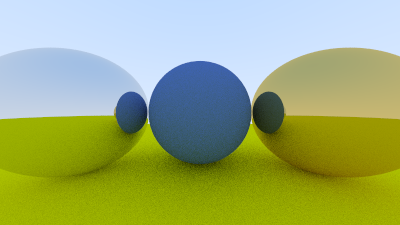

In [10]:
cam.show()
